In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
import pandas as pd

nav = pd.read_csv("Data/Processed/02_nav_history_clean.csv")
benchmark = pd.read_csv("Data/Processed/10_benchmark_indices_clean.csv")
fund_master = pd.read_csv("Data/Processed/01_fund_master_clean.csv")
performance = pd.read_csv("Data/Processed/07_scheme_performance_clean.csv")

In [3]:
print(nav.columns)

print(benchmark.columns)

print(performance.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [4]:
nav['date'] = pd.to_datetime(nav['date'])

In [5]:
nav = nav.sort_values(
    ['amfi_code','date']
)

In [6]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [7]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change() * 100
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [8]:
nav['daily_return'].describe()

count    45960.000000
mean         0.063105
std          1.029041
min         -5.810201
25%         -0.504211
50%          0.034021
75%          0.632376
max          6.471309
Name: daily_return, dtype: float64

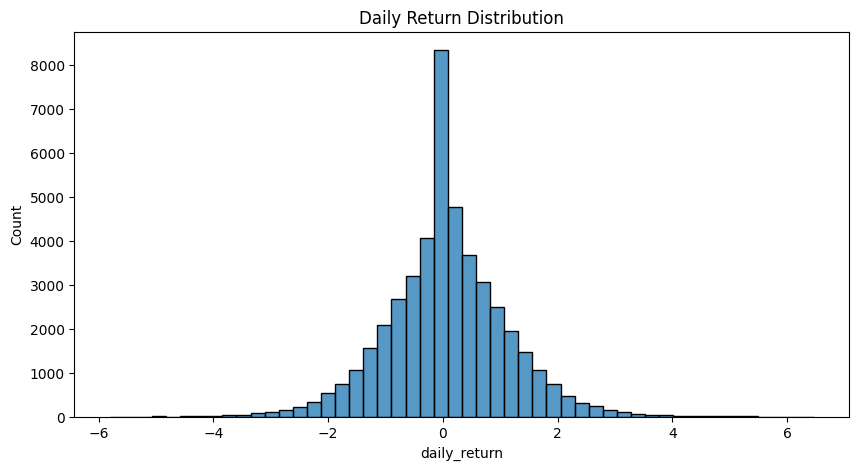

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

In [10]:
nav['amfi_code'].nunique()

40

In [11]:
cagr_list = []

for amfi_code, group in nav.groupby('amfi_code'):

    group = group.sort_values('date')

    start_nav = group['nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]

    years = (group['date'].max() - group['date'].min()).days / 365.25

    if years > 0 and start_nav > 0:

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        cagr_list.append([amfi_code, cagr])

cagr_df = pd.DataFrame(cagr_list, columns=['amfi_code', 'CAGR'])

cagr_df.head()

,amfi_code,CAGR
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [12]:
cagr_df.sort_values('CAGR', ascending=False).head(10)

,amfi_code,CAGR
25,120505,32.827406
21,119598,32.423536
39,149324,32.287440
36,148569,31.949523
34,148567,30.974108
30,120843,30.907455
2,100033,30.123153
38,149323,29.581087
16,119094,28.214417
19,119551,25.804686


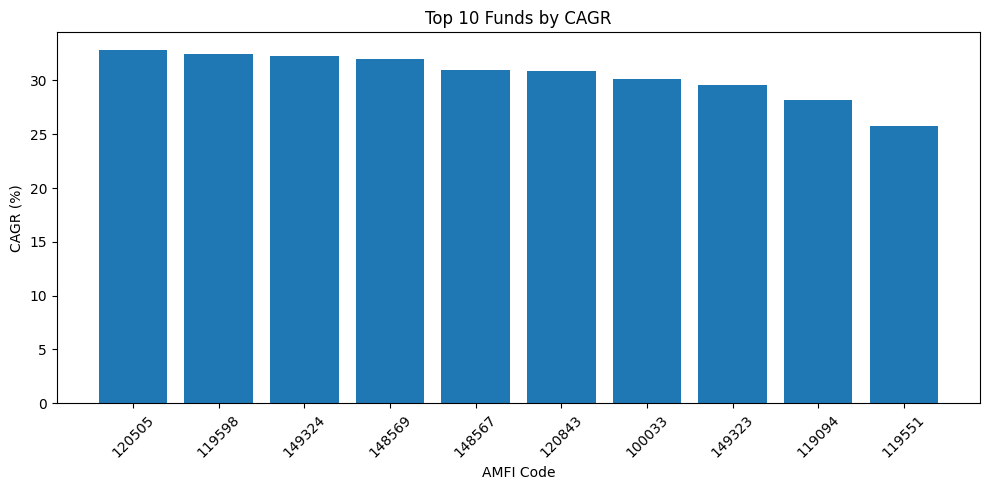

In [13]:
import matplotlib.pyplot as plt

top10 = cagr_df.sort_values('CAGR', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['amfi_code'].astype(str), top10['CAGR'])

plt.title('Top 10 Funds by CAGR')
plt.xlabel('AMFI Code')
plt.ylabel('CAGR (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Reports/charts/cagr_top10.png')
plt.show()

In [14]:
def cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [15]:
cagr_results = []

for fund, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    start_nav = df['nav'].iloc[0]
    end_nav = df['nav'].iloc[-1]

    years = (
        df['date'].max() -
        df['date'].min()
    ).days / 365

    if years > 0:

        fund_cagr = cagr(
            start_nav,
            end_nav,
            years
        )

        cagr_results.append(
            [fund, fund_cagr]
        )

In [17]:
cagr_table = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

In [18]:
cagr_table = cagr_table.sort_values(
    'cagr',
    ascending=False
)

cagr_table.head(10)

,amfi_code,cagr
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499
30,120843,0.308833
2,100033,0.300997
38,149323,0.295581
16,119094,0.281926
19,119551,0.257849


In [19]:
cagr_table['cagr_pct'] = (
    cagr_table['cagr'] * 100
).round(2)

cagr_table.head()

,amfi_code,cagr,cagr_pct
25,120505,0.328016,32.80
21,119598,0.323981,32.40
39,149324,0.322621,32.26
36,148569,0.319245,31.92
34,148567,0.309499,30.95


In [20]:
cagr_table.to_csv(
    "cagr_table.csv",
    index=False
)

In [21]:
print(len(cagr_results))

print(cagr_table.shape)

cagr_table.head()

40
(40, 3)


,amfi_code,cagr,cagr_pct
25,120505,0.328016,32.80
21,119598,0.323981,32.40
39,149324,0.322621,32.26
36,148569,0.319245,31.92
34,148567,0.309499,30.95


In [22]:
nav['daily_return']

0             NaN
1       -1.030568
2        1.286515
3       -1.137747
4       -0.120999
           ...   
45995    1.210627
45996   -0.413805
45997   -0.848008
45998   -2.809342
45999   -0.333538
Name: daily_return, Length: 46000, dtype: float64

In [23]:
nav[['amfi_code','date','daily_return']].head()

,amfi_code,date,daily_return
0,100016,2022-01-03,NaN
1,100016,2022-01-04,-1.030568
2,100016,2022-01-05,1.286515
3,100016,2022-01-06,-1.137747
4,100016,2022-01-07,-0.120999


In [24]:
rf = 0.065

In [25]:
import numpy as np

def sharpe_ratio(returns):

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    return (annual_return - rf) / annual_volatility

In [26]:
sharpe_results = []

for fund, df in nav.groupby('amfi_code'):

    returns = df['daily_return'].dropna()

    if len(returns) > 30:

        ratio = sharpe_ratio(returns)

        sharpe_results.append(
            [fund, ratio]
        )

In [27]:
sharpe_table = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

In [28]:
sharpe_table = sharpe_table.sort_values(
    'sharpe_ratio',
    ascending=False
)

In [29]:
sharpe_table.head(10)

,amfi_code,sharpe_ratio
27,120507,13.524344
31,120844,12.447365
5,101208,11.890847
34,148567,1.901661
30,120843,1.711792
19,119551,1.676558
36,148569,1.599024
9,118632,1.536482
25,120505,1.513677
38,149323,1.494736


In [30]:
sharpe_table.to_csv(
    "sharpe_ratio.csv",
    index=False
)

In [31]:
print(len(sharpe_table))

sharpe_table.head()

40


,amfi_code,sharpe_ratio
27,120507,13.524344
31,120844,12.447365
5,101208,11.890847
34,148567,1.901661
30,120843,1.711792


In [32]:
def sortino_ratio(returns):

    downside = returns[
        returns < 0
    ]

    annual_return = returns.mean()*252

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    return (
        annual_return-rf
    )/downside_std

In [33]:
mdd_list = []

for code, df in nav.groupby('amfi_code'):

    running_max = df['nav'].cummax()

    drawdown = (
        df['nav']
        /
        running_max
    ) - 1

    mdd = drawdown.min()

    mdd_list.append(
        [code,mdd]
    )

mdd_df = pd.DataFrame(
    mdd_list,
    columns=['amfi_code','max_drawdown']
)

In [34]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [36]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [37]:
benchmark['benchmark_return'] = (
    benchmark['close_value']
    .pct_change()
)

In [38]:
benchmark[['date', 'close_value', 'benchmark_return']].head()

,date,close_value,benchmark_return
0,2022-01-03,17492.79,NaN
1,2022-01-04,17689.64,0.011253
2,2022-01-05,17835.05,0.008220
3,2022-01-06,17878.51,0.002437
4,2022-01-07,17759.15,-0.006676


In [39]:
alpha_beta = []

for code, df in nav.groupby('amfi_code'):

    merged = pd.merge(
        df,
        benchmark[['date','benchmark_return']],
        on='date'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        reg = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = reg.slope

        alpha = reg.intercept * 252

        alpha_beta.append(
            [code,alpha,beta]
        )

In [41]:
alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

In [42]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

In [44]:
print(type(cagr_table))
print(type(alpha_beta))
print(type(mdd_df))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [47]:
scorecard = (
    cagr_table
    .merge(sharpe_table, on='amfi_code')
    .merge(alpha_beta, on='amfi_code')
    .merge(mdd_df, on='amfi_code')
)

In [48]:
scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown
0,120505,0.328016,32.80,1.513677,29.508521,-1.745379,-0.181885
1,119598,0.323981,32.40,1.201269,30.314487,-0.350801,-0.287060
2,149324,0.322621,32.26,1.208852,29.582106,3.666693,-0.311719
3,148569,0.319245,31.92,1.599024,28.080300,1.764127,-0.163967
4,148567,0.309499,30.95,1.901661,26.910673,1.047216,-0.112657


In [51]:
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(
    ascending=False
)

scorecard['alpha_rank'] = scorecard['alpha'].rank(
    ascending=False
)

scorecard['mdd_rank'] = scorecard['max_drawdown'].rank(
    ascending=True
)

In [52]:
scorecard['overall_score'] = (
    scorecard['cagr_rank']
    + scorecard['sharpe_rank']
    + scorecard['alpha_rank']
    + scorecard['mdd_rank']
)

In [53]:
scorecard['overall_rank'] = scorecard['overall_score'].rank(
    ascending=True
)

In [54]:
scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,mdd_rank,overall_score,overall_rank
0,120505,0.328016,32.80,1.513677,29.508521,-1.745379,-0.181885,1.0,9.0,3.0,16.0,29.0,1.0
1,119598,0.323981,32.40,1.201269,30.314487,-0.350801,-0.287060,2.0,23.0,1.0,5.0,31.0,2.5
2,149324,0.322621,32.26,1.208852,29.582106,3.666693,-0.311719,3.0,22.0,2.0,4.0,31.0,2.5
3,148569,0.319245,31.92,1.599024,28.080300,1.764127,-0.163967,4.0,7.0,4.0,20.0,35.0,4.0
4,148567,0.309499,30.95,1.901661,26.910673,1.047216,-0.112657,5.0,4.0,6.0,33.0,48.0,8.0


In [55]:
scorecard.sort_values('overall_rank').head(10)

,amfi_code,cagr,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,mdd_rank,overall_score,overall_rank
0,120505,0.328016,32.80,1.513677,29.508521,-1.745379,-0.181885,1.0,9.0,3.0,16.0,29.0,1.0
1,119598,0.323981,32.40,1.201269,30.314487,-0.350801,-0.287060,2.0,23.0,1.0,5.0,31.0,2.5
2,149324,0.322621,32.26,1.208852,29.582106,3.666693,-0.311719,3.0,22.0,2.0,4.0,31.0,2.5
3,148569,0.319245,31.92,1.599024,28.080300,1.764127,-0.163967,4.0,7.0,4.0,20.0,35.0,4.0
5,120843,0.308833,30.88,1.711792,27.321126,-0.436989,-0.129740,6.0,5.0,5.0,28.0,44.0,5.0
7,149323,0.295581,29.56,1.494736,26.573262,0.125950,-0.172481,8.0,10.0,8.0,19.0,45.0,6.0
4,148567,0.309499,30.95,1.901661,26.910673,1.047216,-0.112657,5.0,4.0,6.0,33.0,48.0,8.0
6,100033,0.300997,30.10,1.433515,26.875229,2.409660,-0.162172,7.0,13.0,7.0,21.0,48.0,8.0
8,119094,0.281926,28.19,1.329810,26.273169,-2.872862,-0.209609,9.0,17.0,9.0,13.0,48.0,8.0
10,118632,0.240312,24.03,1.536482,21.578525,1.615660,-0.174141,11.0,8.0,12.0,18.0,49.0,10.0


In [56]:
scorecard['score'] = (
    0.30 * scorecard['cagr_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.25 * scorecard['mdd_rank']
)

In [57]:
scorecard['final_rank'] = scorecard['score'].rank(
    ascending=True
)

In [58]:
scorecard.sort_values('final_rank').head(10)

,amfi_code,cagr,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,mdd_rank,overall_score,overall_rank,score,final_rank
0,120505,0.328016,32.80,1.513677,29.508521,-1.745379,-0.181885,1.0,9.0,3.0,16.0,29.0,1.0,7.15,1.0
1,119598,0.323981,32.40,1.201269,30.314487,-0.350801,-0.287060,2.0,23.0,1.0,5.0,31.0,2.5,7.80,2.0
2,149324,0.322621,32.26,1.208852,29.582106,3.666693,-0.311719,3.0,22.0,2.0,4.0,31.0,2.5,7.80,3.0
3,148569,0.319245,31.92,1.599024,28.080300,1.764127,-0.163967,4.0,7.0,4.0,20.0,35.0,4.0,8.75,4.0
5,120843,0.308833,30.88,1.711792,27.321126,-0.436989,-0.129740,6.0,5.0,5.0,28.0,44.0,5.0,11.05,5.0
7,149323,0.295581,29.56,1.494736,26.573262,0.125950,-0.172481,8.0,10.0,8.0,19.0,45.0,6.0,11.25,6.0
4,148567,0.309499,30.95,1.901661,26.910673,1.047216,-0.112657,5.0,4.0,6.0,33.0,48.0,8.0,11.95,7.0
6,100033,0.300997,30.10,1.433515,26.875229,2.409660,-0.162172,7.0,13.0,7.0,21.0,48.0,8.0,12.00,8.5
8,119094,0.281926,28.19,1.329810,26.273169,-2.872862,-0.209609,9.0,17.0,9.0,13.0,48.0,8.0,12.00,8.5
10,118632,0.240312,24.03,1.536482,21.578525,1.615660,-0.174141,11.0,8.0,12.0,18.0,49.0,10.0,12.20,10.0


In [59]:
scorecard.to_csv(
    "scorecard.csv",
    index=False
)

In [62]:
top5_codes = (
    scorecard
    .sort_values('final_rank')
    .head(5)['amfi_code']
    .tolist()
)

print(top5_codes)

[120505, 119598, 149324, 148569, 120843]


In [63]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


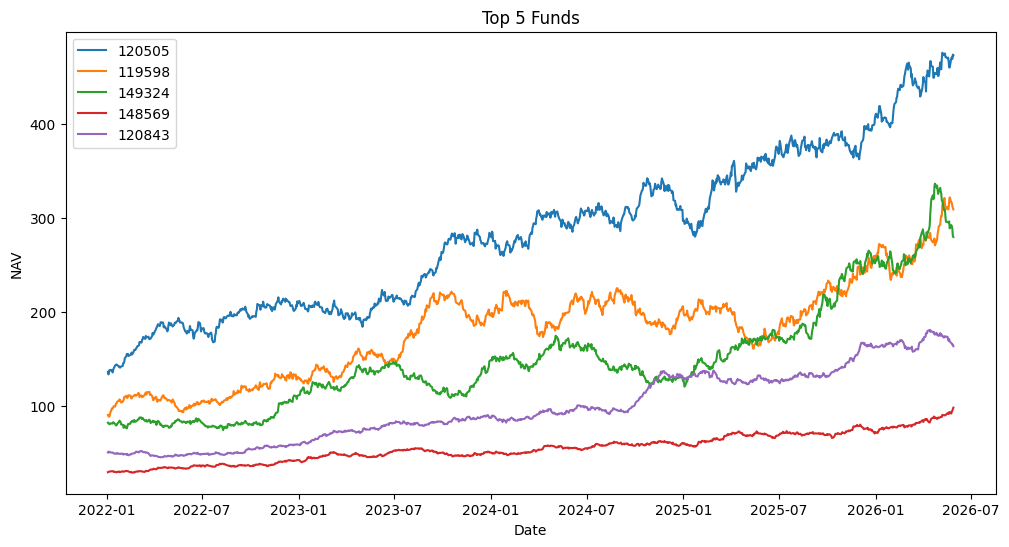

In [64]:
plt.figure(figsize=(12,6))

for code in top5_codes:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.legend()

plt.title("Top 5 Funds")

plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig("benchmark_comparison.png")

plt.show()

In [65]:
print(nav.columns)
print(benchmark.columns)
print(performance.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')
Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [66]:
rf = 0.065

sharpe_results = []

for code, df in nav.groupby('amfi_code'):

    returns = df['daily_return'].dropna()

    if len(returns) > 30:

        annual_return = returns.mean() * 252

        annual_vol = returns.std() * (252 ** 0.5)

        sharpe = (annual_return - rf) / annual_vol

        sharpe_results.append(
            [code, sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio_calc'
    ]
)

In [67]:
sharpe_df.head()

,amfi_code,sharpe_ratio_calc
0,100016,0.240808
1,100025,1.080689
2,100033,1.433515
3,101206,1.468928
4,101207,0.412105


In [68]:
sortino_results = []

for code, df in nav.groupby('amfi_code'):

    returns = df['daily_return'].dropna()

    downside = returns[returns < 0]

    if len(downside) > 10:

        annual_return = returns.mean() * 252

        downside_std = (
            downside.std()
            * np.sqrt(252)
        )

        sortino = (
            annual_return - rf
        ) / downside_std

        sortino_results.append(
            [code, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio_calc'
    ]
)

In [69]:
mdd_results = []

for code, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    running_max = df['nav'].cummax()

    drawdown = (
        df['nav']
        /
        running_max
    ) - 1

    mdd = drawdown.min()

    mdd_results.append(
        [code, mdd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown_calc'
    ]
)

In [70]:
mdd_df.head()

,amfi_code,max_drawdown_calc
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [71]:
benchmark['benchmark_return'] = (
    benchmark['close_value']
    .pct_change()
)

In [72]:
from scipy.stats import linregress

alpha_beta = []

for code, df in nav.groupby('amfi_code'):

    merged = pd.merge(
        df,
        benchmark[
            ['date','benchmark_return']
        ],
        on='date'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        reg = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = reg.intercept * 252
        beta = reg.slope

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha_calc',
        'beta_calc'
    ]
)

In [73]:
scorecard = (
    cagr_table
    .merge(sharpe_df,on='amfi_code')
    .merge(sortino_df,on='amfi_code')
    .merge(mdd_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
)

In [74]:
scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe_ratio_calc,sortino_ratio_calc,max_drawdown_calc,alpha_calc,beta_calc
0,120505,0.328016,32.80,1.513677,2.602985,-0.181885,29.508521,-1.745379
1,119598,0.323981,32.40,1.201269,2.128941,-0.287060,30.314487,-0.350801
2,149324,0.322621,32.26,1.208852,2.061590,-0.311719,29.582106,3.666693
3,148569,0.319245,31.92,1.599024,2.779888,-0.163967,28.080300,1.764127
4,148567,0.309499,30.95,1.901661,3.132441,-0.112657,26.910673,1.047216


In [75]:
scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe_ratio_calc,sortino_ratio_calc,max_drawdown_calc,alpha_calc,beta_calc
0,120505,0.328016,32.80,1.513677,2.602985,-0.181885,29.508521,-1.745379
1,119598,0.323981,32.40,1.201269,2.128941,-0.287060,30.314487,-0.350801
2,149324,0.322621,32.26,1.208852,2.061590,-0.311719,29.582106,3.666693
3,148569,0.319245,31.92,1.599024,2.779888,-0.163967,28.080300,1.764127
4,148567,0.309499,30.95,1.901661,3.132441,-0.112657,26.910673,1.047216


In [76]:
perf_cols = performance[
    [
        'amfi_code',
        'return_3yr_pct',
        'expense_ratio_pct'
    ]
]

scorecard = scorecard.merge(
    perf_cols,
    on='amfi_code',
    how='left'
)

In [77]:
scorecard.head()

,amfi_code,cagr,cagr_pct,sharpe_ratio_calc,sortino_ratio_calc,max_drawdown_calc,alpha_calc,beta_calc,return_3yr_pct,expense_ratio_pct
0,120505,0.328016,32.80,1.513677,2.602985,-0.181885,29.508521,-1.745379,18.08,1.36
1,119598,0.323981,32.40,1.201269,2.128941,-0.287060,30.314487,-0.350801,23.39,1.43
2,149324,0.322621,32.26,1.208852,2.061590,-0.311719,29.582106,3.666693,20.08,1.52
3,148569,0.319245,31.92,1.599024,2.779888,-0.163967,28.080300,1.764127,13.58,1.60
4,148567,0.309499,30.95,1.901661,3.132441,-0.112657,26.910673,1.047216,14.81,1.46


In [78]:
scorecard['rank_3yr'] = scorecard[
    'return_3yr_pct'
].rank(ascending=False)

scorecard['rank_sharpe'] = scorecard[
    'sharpe_ratio_calc'
].rank(ascending=False)

scorecard['rank_alpha'] = scorecard[
    'alpha_calc'
].rank(ascending=False)

In [79]:
scorecard['rank_expense'] = scorecard[
    'expense_ratio_pct'
].rank(ascending=True)

In [81]:
scorecard['rank_drawdown'] = scorecard[
    'max_drawdown_calc'
].rank(ascending=False)

In [82]:
n = len(scorecard)

for col in [
    'rank_3yr',
    'rank_sharpe',
    'rank_alpha',
    'rank_expense',
    'rank_drawdown'
]:
    
    scorecard[col + '_score'] = (
        (n - scorecard[col] + 1)
        / n
    ) * 100

In [83]:
scorecard['fund_score'] = (

      0.30 * scorecard['rank_3yr_score']
    + 0.25 * scorecard['rank_sharpe_score']
    + 0.20 * scorecard['rank_alpha_score']
    + 0.15 * scorecard['rank_expense_score']
    + 0.10 * scorecard['rank_drawdown_score']

)

In [84]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

In [85]:
scorecard[
    [
        'amfi_code',
        'fund_score',
        'return_3yr_pct',
        'sharpe_ratio_calc',
        'alpha_calc'
    ]
].head(10)

,amfi_code,fund_score,return_3yr_pct,sharpe_ratio_calc,alpha_calc
0,120505,77.5000,18.08,1.513677,29.508521
5,120843,77.1250,15.65,1.711792,27.321126
4,148567,73.6250,14.81,1.901661,26.910673
6,100033,72.0000,16.58,1.433515,26.875229
1,119598,70.0000,23.39,1.201269,30.314487
12,120504,67.6250,14.41,1.474526,21.609065
7,149323,65.7500,17.16,1.494736,26.573262
2,149324,64.0625,20.08,1.208852,29.582106
8,119094,62.7500,15.18,1.329810,26.273169
10,118632,60.8125,14.00,1.536482,21.578525


In [86]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [87]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [88]:
import os

print(os.path.exists("fund_scorecard.csv"))
print(os.path.exists("alpha_beta.csv"))

True
True


In [89]:
benchmark['index_name'].unique()

<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [90]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()

print(top5_codes)

[120505, 120843, 148567, 100033, 119598]


In [91]:
top5_nav = nav[
    nav['amfi_code'].isin(top5_codes)
].copy()

In [92]:
top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [93]:
bench = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50','NIFTY100']
    )
].copy()

In [94]:
bench['normalized_index'] = (
    bench.groupby('index_name')['close_value']
    .transform(lambda x: x / x.iloc[0] * 100)
)

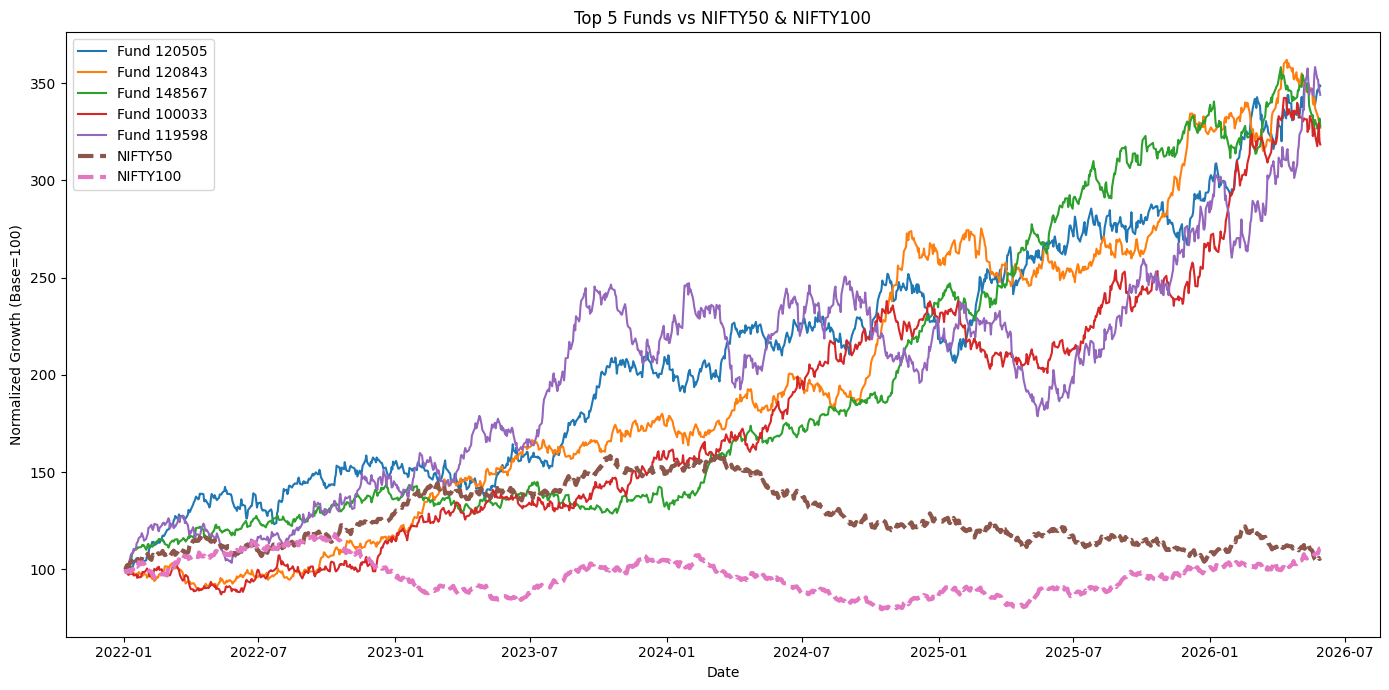

In [95]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = top5_nav[
        top5_nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=f'Fund {code}'
    )

for idx in ['NIFTY50','NIFTY100']:

    temp = bench[
        bench['index_name'] == idx
    ]

    plt.plot(
        temp['date'],
        temp['normalized_index'],
        linestyle='--',
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300
)

plt.show()

In [96]:
tracking_errors = []

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
][['date','benchmark_return']]

In [97]:
for code in top5_codes:

    fund = nav[
        nav['amfi_code'] == code
    ][['date','daily_return']]

    merged = pd.merge(
        fund,
        nifty50,
        on='date'
    ).dropna()

    te = (
        (
            merged['daily_return']
            -
            merged['benchmark_return']
        ).std()
    ) * np.sqrt(252)

    tracking_errors.append(
        [code, te]
    )

In [98]:
tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,19.292871
1,120843,15.888418
2,148567,14.197571
3,100033,18.938127
4,119598,25.136017


In [99]:
import os

print(
    os.path.exists(
        "fund_scorecard.csv"
    )
)

print(
    os.path.exists(
        "alpha_beta.csv"
    )
)

print(
    os.path.exists(
        "benchmark_comparison.png"
    )
)

True
True
True
